In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

### Loading Data

In [ ]:
training_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

classes = training_data.classes
print(classes)

100%|██████████| 170M/170M [00:10<00:00, 16.1MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
training_data, validation_data = torch.utils.data.random_split(training_data, [40000, 10000])

In [ ]:
print(len(training_data),len(validation_data),len(test_data))

40000 10000 10000


## **1 layer network and weight visualisation**

In [ ]:
def mlp(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module('flat_1', torch.nn.Flatten())
    model.add_module('lin_2', torch.nn.Linear(units[0], units[1]))
    model.add_module('sotfmax_3', torch.nn.Softmax(dim=1))

    return model

In [ ]:
model = mlp()
from torchsummary import summary
summary(model, (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                   [-1, 10]          30,730
           Softmax-3                   [-1, 10]               0
Total params: 30,730
Trainable params: 30,730
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
----------------------------------------------------------------


#### Training Loop



*   number of epochs : 5         ->    ```nepochs = 5```
*   number of batchs :  128 ->    ```nbatch = 128```
*   L2 regularizer (value of 0.05) ->    ```weight_decay= 0.05```
*   softmax activation ->    ```model.add_module('relu_3', torch.nn.Softmax(dim=1))```
*   categorical-crossentropy loss ->    ```cost_ce = torch.nn.CrossEntropyLoss()```
*   adam optimizer ->    ```optimizer = torch.optim.Adam(model.parameters(), lr=lr)```



In [ ]:
def train_eval(model, lr, nepochs, nbatch, training_data, validation_data, output=True):
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    cost_ce = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay= 0.05)

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        start=time.time()
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(training_loader):
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in test_loader:
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        end=time.time()
        if output:
            print("Epoch %i (dt=%1.2f s): %f, %f, %f, %f"%(epoch, end-start, cost, acc, cost_test, acc_test))
        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)
    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

#### Training

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                   [-1, 10]          30,730
           Softmax-3                   [-1, 10]               0
Total params: 30,730
Trainable params: 30,730
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
----------------------------------------------------------------
Epoch 0 (dt=6.29 s): 2.355303, 0.100725, 2.357464, 0.103400
Epoch 1 (dt=5.91 s): 2.355546, 0.100150, 2.363447, 0.096700
Epoch 2 (dt=6.11 s): 2.357387, 0.099675, 2.363671, 0.097000
Epoch 3 (dt=5.84 s): 2.356228, 0.100900, 2.339931, 0.103200
Epoch 4 (dt=5.92 s): 2.356061, 0.100400, 2.363060, 0.097000


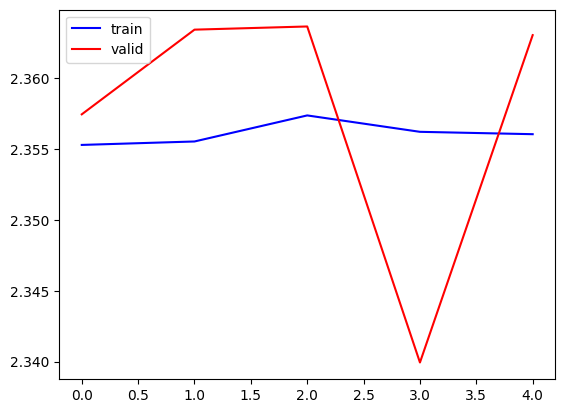

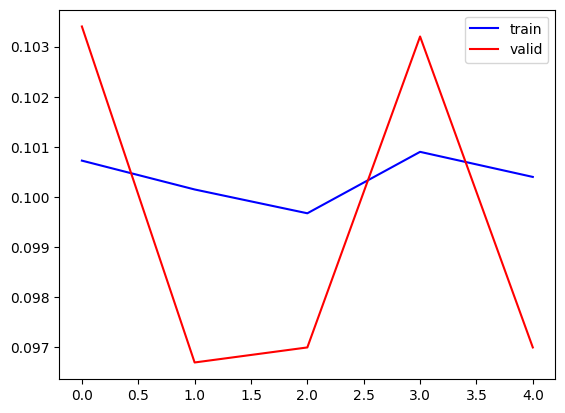

In [ ]:
nbatch = 128
nepochs = 5
lr = 0.01

size_in = training_data[0][0].shape
size_out = len(classes)

summary(model, size_in)

cost_train, cost_valid, acc_train, acc_valid = train_eval(model, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train)), cost_train, "b-", label='train')
plt.plot(range(len(cost_valid)), cost_valid, "r-", label='valid')
plt.legend()
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train)), acc_train, "b-", label='train')
plt.plot(range(len(acc_valid)), acc_valid, "r-", label='valid')
plt.legend()
plt.show()

### Evaluate on test data

In [ ]:
len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred = model(X)

acc_test = (pred.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test:.1f}%')


test accuracy: 10.0%


> A one-layer network is too simple to learn the rules for classyfing those pictures. We can see underfitting. This performance is equivalent to random guessing among the 10 classes.

### Plot weights as image tiles

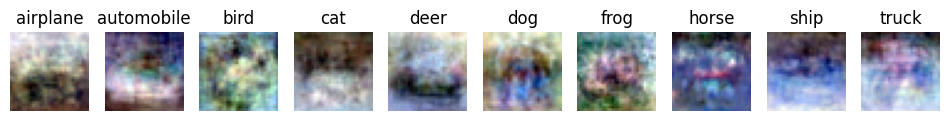

In [ ]:
weights = model[1].weight.detach().reshape([10,3,32,32])
weights = torch.movedim(weights, [1],[3])
min_vals = weights.min(dim=1, keepdim=True).values.min(dim=2, keepdim=True).values
max_vals = weights.max(dim=1, keepdim=True).values.max(dim=2, keepdim=True).values
weights = (weights - min_vals) / (max_vals - min_vals) * 255


figure = plt.figure(figsize=(12, 12))
for col in range(10):
    figure.add_subplot(1, 10, 1+col)
    plt.title(f'{classes[col]}')
    plt.axis("off")
    plt.imshow(weights[col].to(torch.uint8))
plt.show()

## **Two-layers network**



*   128 neurons  ->  ```units = [3*32*32, 128, 10]```
*   30 training epochs
*   batch size of 128 images
*   relu activation on the hidden layer   ->  ```model.add_module('relu_3', torch.nn.ReLU())```
*   a softmax activation at the output lay   -> ```model.add_module('softmax_5', torch.nn.LogSoftmax(dim=1))```
*   categorical-crossentropy loss   -> ```cost_ce = torch.nn.CrossEntropyLoss()```
*   adam optimizer  -> ```optimizer = torch.optim.Adam(model.parameters(), lr=lr)```
*   no L2 regularizer



In [ ]:
def mlp2(units = [3*32*32, 128, 10]):
    model = torch.nn.Sequential()
    model.add_module('flat_1', torch.nn.Flatten())
    model.add_module('lin_2', torch.nn.Linear(units[0], units[1]))
    model.add_module('relu_3', torch.nn.ReLU())
    model.add_module('lin_4', torch.nn.Linear(units[1], units[2]))
    model.add_module('softmax_5', torch.nn.LogSoftmax(dim=1)) #pourquoi log

    return model

In [ ]:
def train_eval2(model, lr, nepochs, nbatch, training_data, validation_data, output=True):
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    cost_ce = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        start=time.time()
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(training_loader):
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in test_loader:
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        end=time.time()
        if output:
            print("Epoch %i (dt=%1.2f s): %f, %f, %f, %f"%(epoch, end-start, cost, acc, cost_test, acc_test))
        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)
    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 128]         393,344
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 10]           1,290
        LogSoftmax-5                   [-1, 10]               0
Total params: 394,634
Trainable params: 394,634
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 1.51
Estimated Total Size (MB): 1.54
----------------------------------------------------------------
Epoch 0 (dt=7.28 s): 1.909224, 0.316375, 1.798989, 0.356700
Epoch 1 (dt=6.80 s): 1.752677, 0.375125, 1.713640, 0.391100
Epoch 2 (dt=7.79 s): 1.682812, 0.402775, 1.745973, 0.362700
Epoch 3 (dt=7.23 s): 1.635470, 0.420400, 1.636344, 0.4

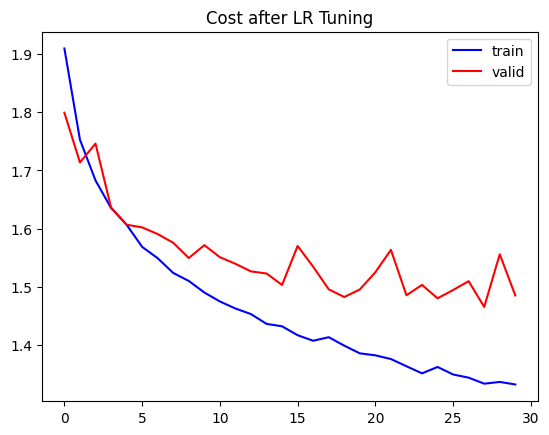

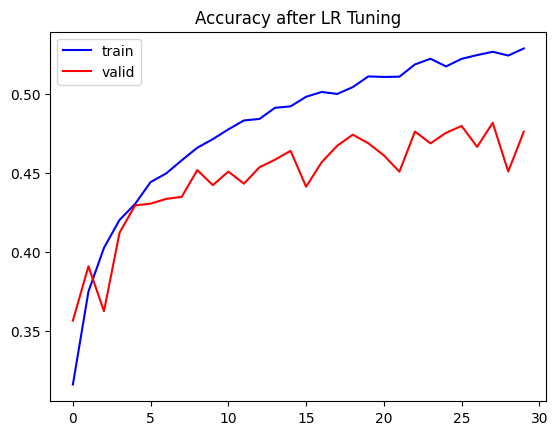

test accuracy after LR tuning: 48.4%


In [ ]:
nbatch = 128
nepochs = 30
lr = 0.001  # 0.01 was too high

size_in = training_data[0][0].shape
size_out = len(classes)

model2 = mlp2()
summary(model2, size_in)

cost_train2_tuned, cost_valid2_tuned, acc_train2_tuned, acc_valid2_tuned = train_eval2(model2, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train2_tuned)), cost_train2_tuned, "b-", label='train')
plt.plot(range(len(cost_valid2_tuned)), cost_valid2_tuned, "r-", label='valid')
plt.legend()
plt.title('Cost after LR Tuning')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train2_tuned)), acc_train2_tuned, "b-", label='train')
plt.plot(range(len(acc_valid2_tuned)), acc_valid2_tuned, "r-", label='valid')
plt.legend()
plt.title('Accuracy after LR Tuning')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred2 = model2(X)

acc_test2_tuned = (pred2.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy after LR tuning: {100*acc_test2_tuned:.1f}%')

In [ ]:
len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred2 = model2(X)

acc_test2 = (pred2.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test2:.1f}%')

test accuracy: 48.4%


> With a better network with an hidding layer and by decreasing the learning rate, we succeed to obtain a test accuracy higher than 45%.

## **Tunning for a better performance**



*   Increasing the number of neurons : from 128 neurons to 256



In [ ]:
def mlp3(units = [3*32*32, 256, 10]):
    model = torch.nn.Sequential()
    model.add_module('flat_1', torch.nn.Flatten())
    model.add_module('lin_2', torch.nn.Linear(units[0], units[1]))
    model.add_module('relu_3', torch.nn.ReLU())
    model.add_module('lin_4', torch.nn.Linear(units[1], units[2]))
    model.add_module('softmax_5', torch.nn.LogSoftmax(dim=1))
    return model

model3 = mlp3()

summary(model3, size_in)

nbatch = 128
nepochs = 30
lr = 0.001

cost_train3, cost_valid3, acc_train3, acc_valid3 = train_eval2(model3, lr, nepochs,
                                nbatch, training_data, validation_data)

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred3 = model3(X)

acc_test3 = (pred3.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test3:.1f}%')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 256]         786,688
              ReLU-3                  [-1, 256]               0
            Linear-4                   [-1, 10]           2,570
        LogSoftmax-5                   [-1, 10]               0
Total params: 789,258
Trainable params: 789,258
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 3.01
Estimated Total Size (MB): 3.05
----------------------------------------------------------------
Epoch 0 (dt=8.46 s): 1.901363, 0.319850, 1.802064, 0.356700
Epoch 1 (dt=8.26 s): 1.732286, 0.385550, 1.702269, 0.399500
Epoch 2 (dt=7.74 s): 1.649416, 0.416175, 1.638625, 0.413200
Epoch 3 (dt=8.26 s): 1.599639, 0.434450, 1.598483, 0.4

> A better accuracy : **48 %**



*   Adding a fully connected layer



In [ ]:
def mlp4(units = [3*32*32, 128, 10]):
    model = torch.nn.Sequential()
    model.add_module('flat_1', torch.nn.Flatten())
    model.add_module('lin_2', torch.nn.Linear(units[0], units[1]))
    model.add_module('relu_3', torch.nn.ReLU())
    model.add_module('lin_4', torch.nn.Linear(units[1], units[2]))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('lin_6', torch.nn.Linear(units[2], units[2]))
    model.add_module('logsoftmax_5', torch.nn.LogSoftmax(dim=1))

    return model

model4 = mlp4()

summary(model4, size_in)

nbatch = 128
nepochs = 30
lr = 0.001

cost_train4, cost_valid4, acc_train4, acc_valid4 = train_eval2(model4, lr, nepochs,
                                nbatch, training_data, validation_data)

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred4 = model4(X)

acc_test4 = (pred4.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test4:.1f}%')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 128]         393,344
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 10]           1,290
              ReLU-5                   [-1, 10]               0
            Linear-6                   [-1, 10]             110
        LogSoftmax-7                   [-1, 10]               0
Total params: 394,744
Trainable params: 394,744
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 1.51
Estimated Total Size (MB): 1.54
----------------------------------------------------------------
Epoch 0 (dt=7.39 s): 2.095237, 0.197650, 2.030551, 0.224900
Epoch 1 (dt=6.89 s): 1.948734, 0.271675, 1.936

>> Accuracy is still around **46%**.



*   Tunning the number of epochs : from 30 to 50



In [ ]:
model5 = mlp2()
summary(model5, size_in)

nbatch = 128
nepochs = 50
lr = 0.01

cost_train5, cost_valid5, acc_train5, acc_valid5 = train_eval2(model5, lr, nepochs,
                                nbatch, training_data, validation_data)

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred5 = model5(X)

acc_test5 = (pred5.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test5:.1f}%')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 128]         393,344
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 10]           1,290
        LogSoftmax-5                   [-1, 10]               0
Total params: 394,634
Trainable params: 394,634
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 1.51
Estimated Total Size (MB): 1.54
----------------------------------------------------------------
Epoch 0 (dt=7.30 s): 2.496859, 0.149550, 2.134390, 0.163300
Epoch 1 (dt=6.71 s): 2.079154, 0.211275, 2.036992, 0.220700
Epoch 2 (dt=7.22 s): 2.026913, 0.227925, 2.018663, 0.237600
Epoch 3 (dt=7.18 s): 2.016722, 0.231325, 1.993155, 0.2

> The accuracy has decreased with the increasing of the number of epochs.

_______________________________________________________

### **Conclusion**:
By adding a fully connected layer or by increasing the number of neurons in front of them, the accuracy slightly increases but stays around 46%. The best solution would be to combine those enhancements.